In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [12]:
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print(df.head())
print(df.info())
print(df.describe())

   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 

In [13]:
print(df.isnull().sum())

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


In [14]:
print(df['default'].value_counts())

print(
    df['default'].value_counts(normalize=True)*100
)

default
0    8149
1    1851
Name: count, dtype: int64
default
0    81.49
1    18.51
Name: proportion, dtype: float64


In [15]:
X = df.drop(
    ['customer_id', 'default'],
    axis=1
)

y = df['default']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(
    X_test
)[:,1]

In [19]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(
    X_test
)[:,1]

In [20]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.997
ROC AUC: 0.9999784447023711
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



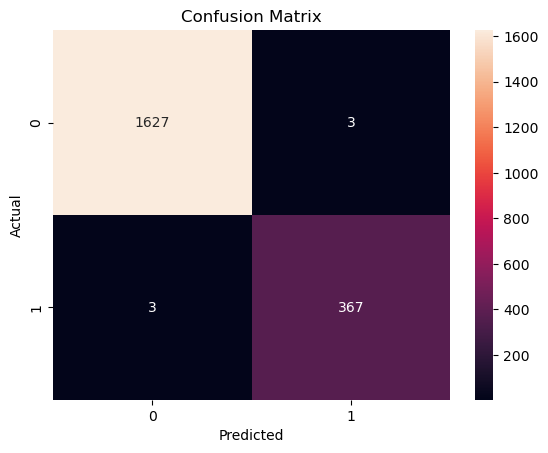

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

In [22]:
pd_values = model.predict_proba(
    X
)[:,1]

df['PD'] = pd_values

print(
    df[
        ['customer_id',
         'PD']
    ].head()
)

   customer_id            PD
0      8153374  3.700429e-19
1      7442532  1.000000e+00
2      2256073  1.028021e-17
3      4885975  9.813979e-20
4      4700614  4.518946e-12


In [23]:
LGD = 0.5

df['Expected_Loss'] = (
    df['PD']
    * df['loan_amt_outstanding']
    * LGD
)

print(
    df[
        ['customer_id',
         'Expected_Loss']
    ].head()
)

   customer_id  Expected_Loss
0      8153374   9.660978e-16
1      7442532   9.794644e+02
2      2256073   1.728621e-14
3      4885975   2.338989e-16
4      4700614   3.040861e-09


In [24]:
total_loss = (
    df['Expected_Loss']
    .sum()
)

print(
    f"Total Expected Loss: ${total_loss:,.2f}"
)

Total Expected Loss: $4,125,756.69


A logistic regression model was built to estimate the probability of default for each customer using demographic and financial variables such as income, debt, FICO score, and employment history. The predicted probability of default was then used to estimate expected losses by multiplying the probability of default with the outstanding loan amount and an assumed loss given default (LGD).